# 전략 성과 민감도 — 독성 가중치 γ · 감성 이동평균 기간

파라미터를 바꿔가며 **K-FGI → 포지션 → 전략수익률**을 10년 전 구간 재산출하고, Sharpe · MDD · CVaR(5%) · 하방 변동성 · 하락일 방어율 · Calmar 를 비교한다.

- 실험 1: γ ∈ {1, 2, 3} — 댓글 → 일별 감성피처 6종 재계산 → `KFG_final` 감성열 치환 → 전 파이프라인 재실행
- 실험 2: 감성 복합지표 이동평균 기간 ∈ {5, 10, 20} 거래일 (γ = 2 고정)

**주의** — EGARCH 조건부 변동성은 수익률만의 함수이므로 캐시(`08_Modeling/experiment_outputs/cache/egarch_vol_10y.csv`)를 재사용한다. walk-forward K-FGI 재추정 때문에 6회 실행에 약 8~12분 소요된다. 결과는 `downstream_sensitivity.csv` 에 저장된다.

In [1]:
import pandas as pd, numpy as np
import downstream_strategy_sensitivity as D
import filter_param_lib as L
%matplotlib inline
import matplotlib.pyplot as plt
LANG = "ko"
L.use_style(LANG)

## 실행
최초 실행은 8~12분. `downstream_sensitivity.csv` 가 이미 있으면 아래 표·그림 셀만 실행해도 된다.

In [2]:
kfg = pd.read_csv(D.KFG_FINAL, parse_dates=['date']).sort_values('date').reset_index(drop=True)
mkt = kfg[['date','log_return_t+1']].rename(columns={'log_return_t+1':'mkt'}).set_index('date')['mkt']
comments = D.load_comments()
SENT = ['sent_norm_w','sent_strength_w','sent_std','neg_z','effective_n','heat']
def swap_sent(gamma):
    ds = D.daily_sentiment(comments, gamma)
    m = kfg.drop(columns=SENT).merge(ds, on='date', how='left')
    m[SENT] = m[SENT].ffill()
    return m

In [3]:
# downstream_sensitivity.csv 가 이미 있으면 재사용한다. 다시 계산하려면 그 파일을 삭제하고 실행.
CSV = D.BASE / 'downstream_sensitivity.csv'
if CSV.exists():
    out = pd.read_csv(CSV)
    print('loaded cached', CSV.name)
else:
    rows = []
    for g in [1.0, 2.0, 3.0]:
        res = D.run_pipeline(swap_sent(g), sent_ma_window=10)
        mm = D.metrics(res['strat_ret'].reset_index(drop=True), mkt.reindex(res['date']).reset_index(drop=True), f'gamma={g:g}')
        mm['experiment'], mm['param'] = 'gamma', g; rows.append(mm); print('gamma', g, 'done')
    base2 = swap_sent(2.0)
    for w in [5, 10, 20]:
        res = D.run_pipeline(base2, sent_ma_window=w)
        mm = D.metrics(res['strat_ret'].reset_index(drop=True), mkt.reindex(res['date']).reset_index(drop=True), f'sent_MA={w}')
        mm['experiment'], mm['param'] = 'sent_ma', w; rows.append(mm); print('sent_MA', w, 'done')
    out = pd.DataFrame(rows); out.to_csv(CSV, index=False)
out[['experiment','param','sharpe','mdd','cvar5','downside_vol','downday_defense','calmar','total_return']].round(4)

loaded cached downstream_sensitivity.csv


,experiment,param,sharpe,mdd,cvar5,downside_vol,downday_defense,calmar,total_return
0,gamma,1.0,0.6096,-0.2291,-0.0213,0.1144,0.5872,0.3619,1.2804
1,gamma,2.0,0.6127,-0.2293,-0.0213,0.1143,0.5863,0.3633,1.2892
2,gamma,3.0,0.6222,-0.2291,-0.0213,0.1145,0.5867,0.3703,1.3237
3,sent_ma,5.0,0.5459,-0.2535,-0.0217,0.1171,0.6031,0.2972,1.1148
4,sent_ma,10.0,0.6127,-0.2293,-0.0213,0.1143,0.5863,0.3633,1.2892
5,sent_ma,20.0,0.5391,-0.2732,-0.0234,0.1258,0.6404,0.2906,1.2017


## 결과

### H1

γ 1·2·3 각각으로 댓글 → 일별 감성피처 → K-FGI → 포지션 → 전략수익률을 10년 전 구간 재산출한 결과. Sharpe 0.610 / 0.613 / 0.622, Calmar 0.36 부근으로 사실상 평평하다. γ=2 는 성과 최적값이 아니다.

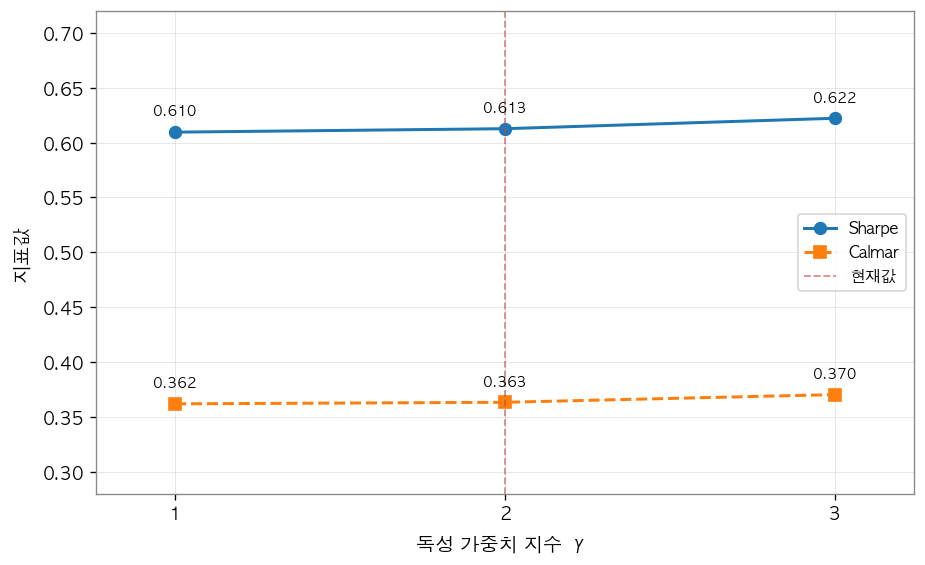

In [4]:
L.make_fig("H1", None, LANG)

### H2

MDD −22.9%, CVaR(5%) −2.13%, 하방 변동성 0.114 로 γ 1→3 에서 소수 셋째 자리까지 변화가 없다. 독성 가중치 지수는 전략의 하방위험에 영향을 주지 않는다.

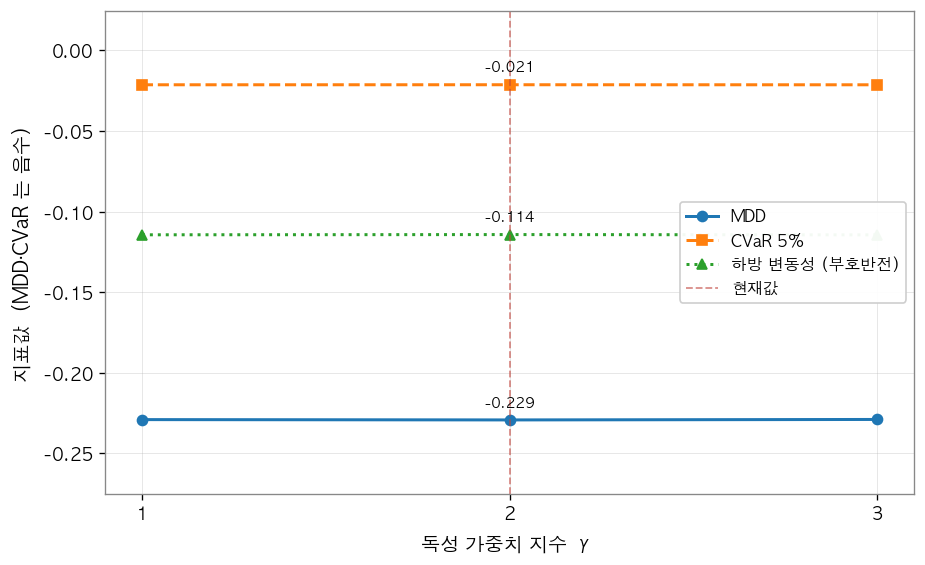

In [5]:
L.make_fig("H2", None, LANG)

### I1

sent_composite 를 5·10·20 거래일로 평활한 각 경우의 전략 성과. 10일이 Sharpe(0.61)·Calmar(0.36)·MDD(−22.9%) 모두에서 최적인 뚜렷한 국소 최적점이다. 5일은 노이즈, 20일은 반응 지연으로 나빠진다. (τ·γ 와 달리 이 값은 결과에 민감하므로 반드시 근거가 필요하다.)

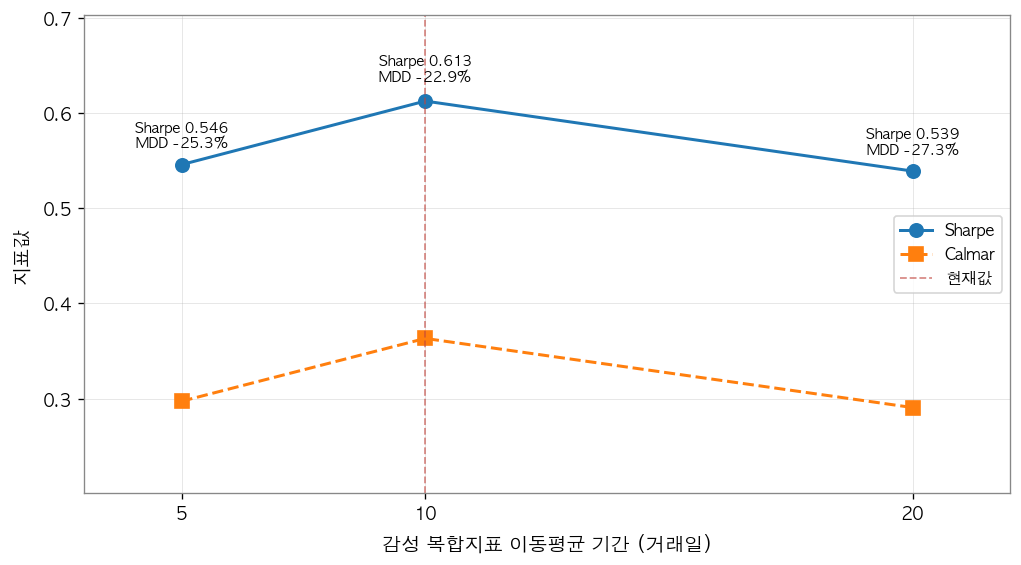

In [6]:
L.make_fig("I1", None, LANG)

## 해석

- **γ 는 전략 성과에 영향이 없다.** γ 1·2·3 에서 Sharpe 0.610 / 0.613 / 0.622, MDD −22.9% 고정. 따라서 γ = 2 는 성과로 고른 값이 아니라 댓글 가중 원칙(경계 독성 절반 감쇠)으로 정한 값이다.
- **감성 이동평균 10일은 명확한 국소 최적이다.** 5일(Sharpe 0.55) 은 노이즈, 20일(Sharpe 0.54, MDD −27.3%) 은 반응 지연. 이 값은 τ·γ 와 달리 결과에 민감하므로 반드시 근거가 필요하며, 그 근거가 이 표다.